In [1]:
import numpy as np
from bhjet import BLJet, BHJet
import matplotlib.pyplot as plt
import matplotlib.animation as animation
%matplotlib widget
from tqdm import trange

In [2]:
erg2eV = 6.242e+11 # 1erg in eV
eV2erg = 1/erg2eV
c = 3e10 # cm/s
pc = 3.086e18 # cm

In [3]:
sim_type = "xrb" # M87 or xrb
dlgzs = [0.5, 0.3, 0.1, 0.03]

In [4]:
bljets = []
for dlgz in dlgzs:
    if sim_type == "M87":
        bljets.append(BLJet(
            mass_bh=1e9, # M_sun
            jet_power_eddington=1e-5, # in units of the Eddington Luminosity
            z_jet_launching=2, # in units of rg
            r_initial=3, # in units of rg
            z_end_of_acceleration=1e5, # in units of rg
            z_dissipation=1e2, # in units of rg
            z_max_calculation=1e6, # in units of rg
            sigma_final=1,
            gamma_final=15, # Lorentz factor
            plasma_beta_jet_base=1,
            electron_temperature_jet_base=1e4, # keV
            gamma_acceleration_exponent=0.5,
            opening_angle_constant=0.15,
            fraction_nonthermal_electrons=1e-1, 
            fraction_nonthermal_protons=0.1, 
            factor_break_electrons=1, 
            factor_break_protons=1, 
            factor_max_energy_electrons=1, 
            factor_max_energy_protons=1, 
            index_injected_electrons=2, 
            index_injected_protons=2, 
            dlgz=dlgz,
            verbosity_level=1
        ))
    elif sim_type == "xrb":
        bljets.append(BLJet(
            mass_bh=9.8, # M_sun
            jet_power_eddington=0.09, # in units of the Eddington Luminosity
            z_jet_launching=360, # in units of rg
            r_initial=181, # in units of rg
            z_end_of_acceleration=1e4, # in units of rg
            z_dissipation=1e4, # in units of rg
            z_max_calculation=1e8, # in units of rg
            sigma_final=0.1,
            gamma_final=3, # Lorentz factor
            plasma_beta_jet_base=0.1,
            electron_temperature_jet_base=5e2, # keV
            gamma_acceleration_exponent=0.5,
            opening_angle_constant=0.15,
            fraction_nonthermal_electrons=1e-1, 
            fraction_nonthermal_protons=0.1, 
            factor_break_electrons=0.1, 
            factor_break_protons=1, 
            factor_max_energy_electrons=1e-6, 
            factor_max_energy_protons=1, 
            index_injected_electrons=2, 
            index_injected_protons=2, 
            dlgz=dlgz,
            calc_pair_content_from_plasma_beta=True,
            verbosity_level=1
        ))
    else:
        print(f"sim_type {sim_type} not defined")


Text(0, 0.5, '$dlog_{10}z$')

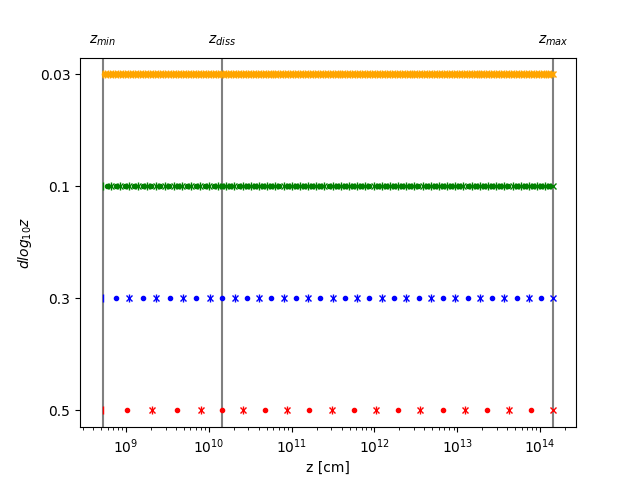

In [5]:
fig, ax = plt.subplots()
cols = ["r", "b", "g", "orange", "c"]
height = 0
for i in range(len(dlgzs)):
    bljet = bljets[i]
    bljet.compute_jet_dynamics()
    ax.semilogx(bljet.get_z_min_grid(), height*np.ones_like(bljet.get_z_min_grid()), ls="", marker="|", c=cols[i])
    ax.semilogx(bljet.get_z_center_grid(), height*np.ones_like(bljet.get_z_min_grid()), ls="", marker=".", c=cols[i])
    ax.semilogx(bljet.get_z_min_grid()+bljet.get_z_height_grid(), height*np.ones_like(bljet.get_z_min_grid()), ls="", marker="x", c=cols[i], ms=4)
    height += 1
ax.axvline(bljet.z_jet_launching*bljet.r_g, zorder=0, c="grey")
ax.text(bljet.z_jet_launching*bljet.r_g, height-0.7, r"$z_{min}$", va='center', ha="center")
ax.axvline(bljet.z_dissipation*bljet.r_g, zorder=0, c="grey")
ax.text(bljet.z_dissipation*bljet.r_g, height-0.7, r"$z_{diss}$", va='center', ha="center")
ax.axvline(bljet.z_max_calculation*bljet.r_g, zorder=0, c="grey")
ax.text(bljet.z_max_calculation*bljet.r_g, height-0.7, r"$z_{max}$", va='center', ha="center")
ax.set_xlabel("z [cm]")
ax.set_yticks(np.arange(len(dlgzs)))
ax.set_yticklabels(dlgzs)
ax.set_ylabel(r"$dlog_{10}z$")


In [6]:
bhjets = []
for dlgz in dlgzs:
    if sim_type == "M87":
        bhjets.append(BHJet(
            theta_obs=17, # degree
            distance=16e3, # kpc 
            redshift=0.00428,
            include_counterjet=True, 
            profile_time=True,
            verbosity_level=1))
    elif sim_type == "xrb":
        bhjets.append(BHJet(
            theta_obs=40, # degree
            distance=8, # kpc 
            redshift=0.0,
            include_counterjet=True, 
            profile_time=True,
            verbosity_level=1))
    else:
        print(f"sim_type {sim_type} not defined")
    
for i in range(len(dlgzs)):
    bhjets[i].init_jet_dynamics(bljets[i])

In [7]:
E_out = np.logspace(-8, 19, 200)
for bhjet in bhjets:
    bhjet.compute_full_jet(photon_energy_grid=E_out * eV2erg)

We can access zone i by `rad = bhjet.radiation_zones[i]`, and read out the information similar to the single_zone_example.ipynb.

Text(0.5, 1.0, 'comoving target photon spectrum at z=5.0e+11')

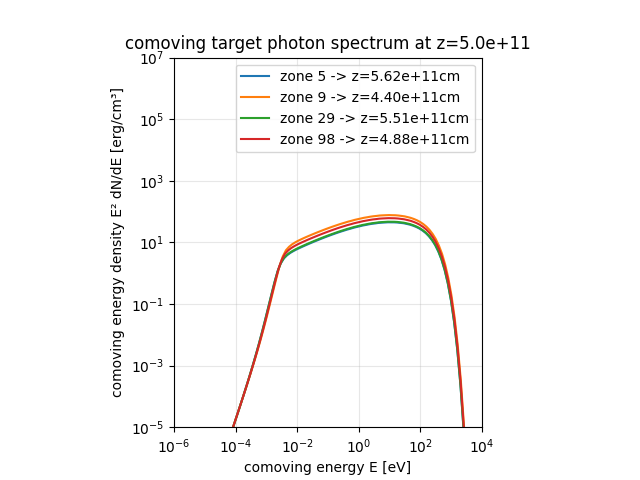

In [8]:
z_zone = bljet.z_dissipation*bljet.r_g # cm
z_zone = 5e11 # cm

fig, axpt = plt.subplots()
for i in range(len(dlgzs)):
    bhjet = bhjets[i]
    bljet = bljets[i]
    zs = bljet.get_z_center_grid() 
    ind_zone = np.argmin((z_zone-zs)**2)
    rad = bhjet.radiation_zones[ind_zone]
    energy = rad.get_photon_target_energy_grid()
    fac = 1 #n_zones_vals[i]/n_zones_vals[0]
    axpt.loglog(energy*erg2eV, 1/fac * rad.get_photon_target_energy_density(), label=f"zone {ind_zone} -> z={bljet.get_z_center_grid()[ind_zone]:.2e}cm")
axpt.legend()
axpt.set_xlabel("comoving energy E [eV]")
axpt.set_ylabel("comoving energy density E² dN/dE [erg/cm³]")
axpt.grid(alpha=0.3)
axpt.set_aspect("equal")
axpt.set_ylim(1e-5, 1e7)
axpt.set_xlim(1e-6, 1e4)
# z_zone = "z_diss"
axpt.set_title(f"comoving target photon spectrum at z={z_zone:.1e}")


183.78428829676662

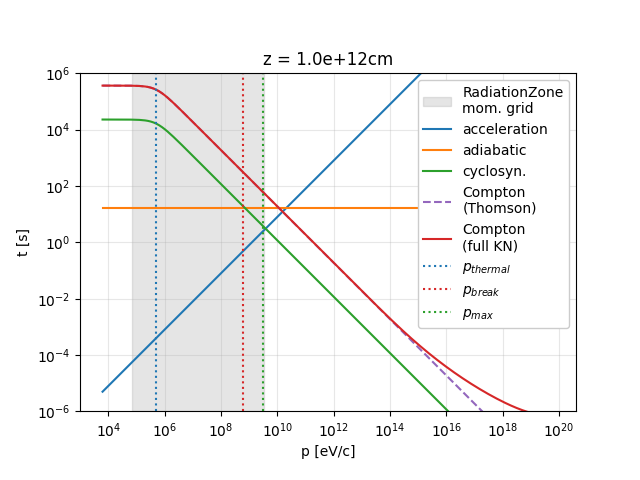

In [9]:
z_zone = 1e12
zs = bljets[-1].get_z_center_grid() 
ind_zone = np.argmin((z_zone-zs)**2)
rad = bhjets[-1].radiation_zones[ind_zone]

fig, axt = plt.subplots()
mom = rad.get_electron_momentum_grid()
axt.axvspan(mom[0]*erg2eV*c, mom[-1]*erg2eV*c, color="grey", alpha=0.2, label="RadiationZone\nmom. grid")
mom = np.logspace(-8, 8, 160) /c
axt.loglog(mom*erg2eV*c, rad.get_timescale_electron_acceleration(mom), c="tab:blue", label="acceleration")
axt.loglog(mom*erg2eV*c, rad.get_timescale_electron_adiabatic(mom), c="tab:orange", label="adiabatic")
axt.loglog(mom*erg2eV*c, rad.get_timescale_electron_cyclosyn(mom), c="tab:green", label="cyclosyn.")
axt.loglog(mom*erg2eV*c, rad.get_timescale_electron_compton_thomson(mom), c="tab:purple", label="Compton\n(Thomson)", ls="--")
axt.loglog(mom*erg2eV*c, rad.get_timescale_electron_compton(mom), c="tab:red", label="Compton\n(full KN)")
axt.axvline(rad.electron_temperature*1e3, ls=":", label=r"$p_{thermal}$")
axt.axvline(rad.get_electron_break_momentum()*erg2eV*c, ls=":", c="tab:red", label=r"$p_{break}$")
axt.axvline(rad.get_electron_max_momentum()*erg2eV*c,ls=":", c="tab:green", label=r"$p_{max}$")
axt.legend(framealpha=1, loc="upper right")
axt.set_title(f"z = {z_zone:.1e}cm")
axt.set_xlabel("p [eV/c]")
axt.set_ylabel("t [s]")
axt.grid(alpha=0.3)
axt.set_aspect("equal")
axt.set_ylim(1e-6, 1e6)
rad.magnetic_field

Text(0, 0.5, 'characteristic electron energy [eV]')

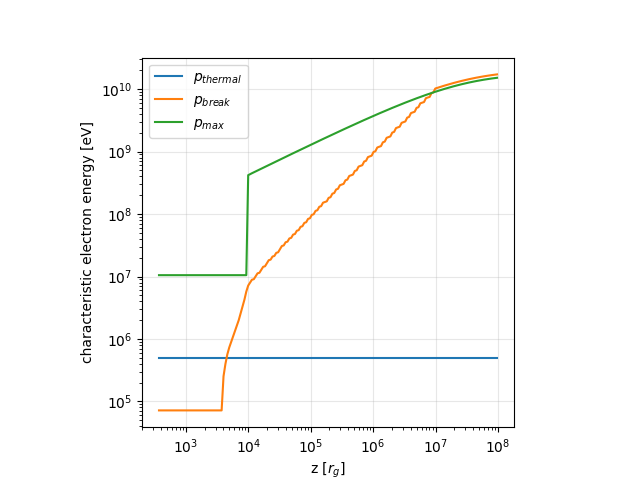

In [10]:
fig, ax = plt.subplots()
p_ths, p_brs, p_maxs = [], [], []
for i in range(bljet.n_zones):
    p_ths.append(bhjet.radiation_zones[i].electron_temperature * 1e3)
    p_brs.append(bhjet.radiation_zones[i].get_electron_break_momentum()*erg2eV*c)
    p_maxs.append(bhjet.radiation_zones[i].get_electron_max_momentum()*erg2eV*c)
ax.loglog(bljet.get_z_center_grid()/bljet.r_g, p_ths, label=r"$p_{thermal}$")
ax.loglog(bljet.get_z_center_grid()/bljet.r_g, p_brs, label=r"$p_{break}$")
ax.loglog(bljet.get_z_center_grid()/bljet.r_g, p_maxs, label=r"$p_{max}$")
ax.set_aspect("equal")
ax.grid(alpha=0.3)
ax.legend()
ax.set_xlabel(r"z [$r_g$]")
ax.set_ylabel(r"characteristic electron energy [eV]")

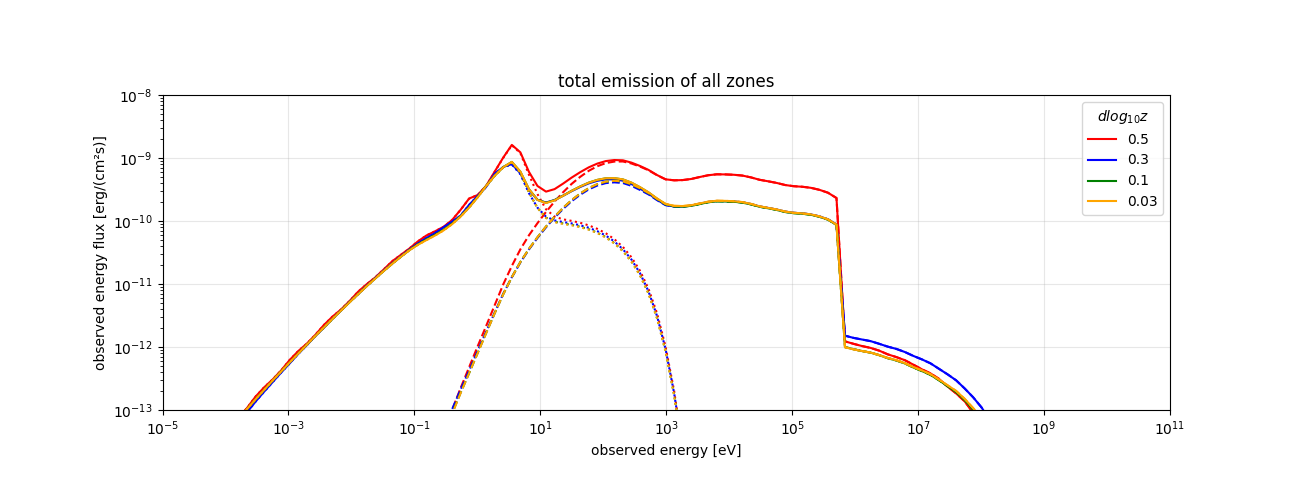

In [11]:
fig, ax = plt.subplots(figsize=(13,5))
# bhjet.set_target_black_body_luminosity("starlight", 1e45)

for i in range(len(dlgzs)):
    bhjet = bhjets[i]
    bljet = bljets[i]
    ax.loglog(E_out, E_out*eV2erg*bhjet.get_observed_photon_integrated_flux_total(
        0, bljet.z_max_calculation*bljet.r_g), label=f"{dlgzs[i]}", color=cols[i])
    ax.loglog(E_out, E_out*eV2erg*bhjet.get_observed_photon_integrated_flux_electron_compton(
        0, bljet.z_max_calculation*bljet.r_g), color=cols[i], ls="--")
    ax.loglog(E_out, E_out*eV2erg*bhjet.get_observed_photon_integrated_flux_electron_cyclosyn(
        0, bljet.z_max_calculation*bljet.r_g), color=cols[i], ls=":")

ax.legend(title=r"$dlog_{10}z$")
ax.set_title("total emission of all zones")
ax.set_xlabel(r"observed energy [eV]")
ax.set_ylabel(r"observed energy flux [erg/(cm²s)]")
ax.set_ylim(1e-13, 1e-8)
ax.set_xlim(1e-5, 1e11)
ax.set_aspect("equal")
ax.grid(alpha=0.3)

(0.001, 10000.0)

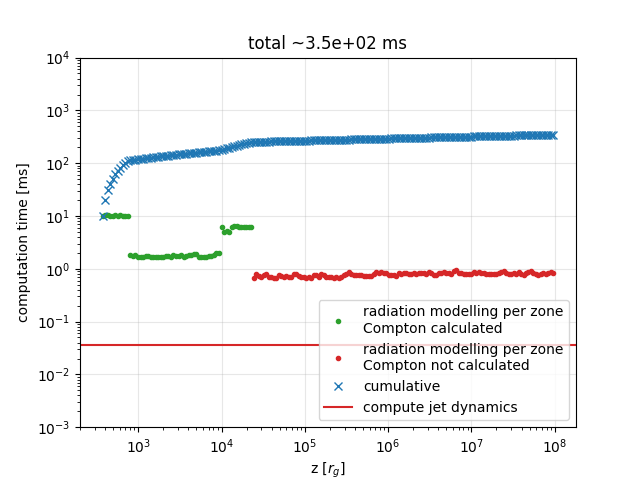

In [12]:
fig, ax = plt.subplots()
mask = np.array([bhjet.radiation_zones[i].compton_calculation_necessary() for i in range(bljet.n_zones)])

ax.loglog(bljet.get_z_center_grid()[mask]/bljet.r_g, 1e-6* bhjet.get_computation_times()[1:][mask],
          ls="", marker=".", label="radiation modelling per zone\nCompton calculated", color='tab:green')
ax.loglog(bljet.get_z_center_grid()[~mask]/bljet.r_g, 1e-6* bhjet.get_computation_times()[1:][~mask],
          ls="", marker=".", label="radiation modelling per zone\nCompton not calculated", color='tab:red')
ax.loglog(bljet.get_z_center_grid()/bljet.r_g, 1e-6* np.cumsum(bhjet.get_computation_times()[1:]),
          ls="", marker="x", label="cumulative")
ax.axhline(1e-6* bhjet.get_computation_times()[0], color="tab:red", label="compute jet dynamics")
ax.set_title(f"total ~{1e-6*np.sum(bhjet.get_computation_times()):.1e} ms")
ax.legend(loc="lower right")
ax.set_xlabel(r"z [$r_g$]")
ax.set_ylabel(r"computation time [ms]")
ax.grid(alpha=0.3)
ax.set_ylim(1e-3, 1e4)

## animation

In [13]:
# Logarithmic steps for z_dissipation
z_diss_vals = np.logspace(
    np.log10(bljet.z_jet_launching),       # z_jet_launching
    np.log10(bljet.z_max_calculation),     # z_max_calculation
    100                # use 100 for testing, change to 1000 for final
)

plotdata = {
    "zmin_grids": [[] for i in dlgzs],
    "zcen_grids": [[] for i in dlgzs],
    "zmax_grids": [[] for i in dlgzs],
    "Efluxs_tot": [[] for i in dlgzs],
    "Efluxs_syn": [[] for i in dlgzs],
    "Efluxs_com": [[] for i in dlgzs],
}

for iz in trange(len(z_diss_vals)):

    for i in range(len(dlgzs)):
        bljet = bljets[i]
        bhjet = bhjets[i]
        bljet.z_dissipation = z_diss_vals[iz]
        bhjet.compute_full_jet(photon_energy_grid=E_out * eV2erg)
        plotdata["zmin_grids"][i].append(bljet.get_z_min_grid())
        plotdata["zcen_grids"][i].append(bljet.get_z_center_grid())
        plotdata["zmax_grids"][i].append(bljet.get_z_min_grid()+bljet.get_z_height_grid())
        plotdata["Efluxs_tot"][i].append(E_out*eV2erg*bhjet.get_observed_photon_integrated_flux_total(
            0, bljet.z_max_calculation*bljet.r_g))
        plotdata["Efluxs_syn"][i].append(E_out*eV2erg*bhjet.get_observed_photon_integrated_flux_electron_compton(
            0, bljet.z_max_calculation*bljet.r_g))
        plotdata["Efluxs_com"][i].append(E_out*eV2erg*bhjet.get_observed_photon_integrated_flux_electron_cyclosyn(
            0, bljet.z_max_calculation*bljet.r_g))



100%|██████████| 100/100 [00:47<00:00,  2.12it/s]


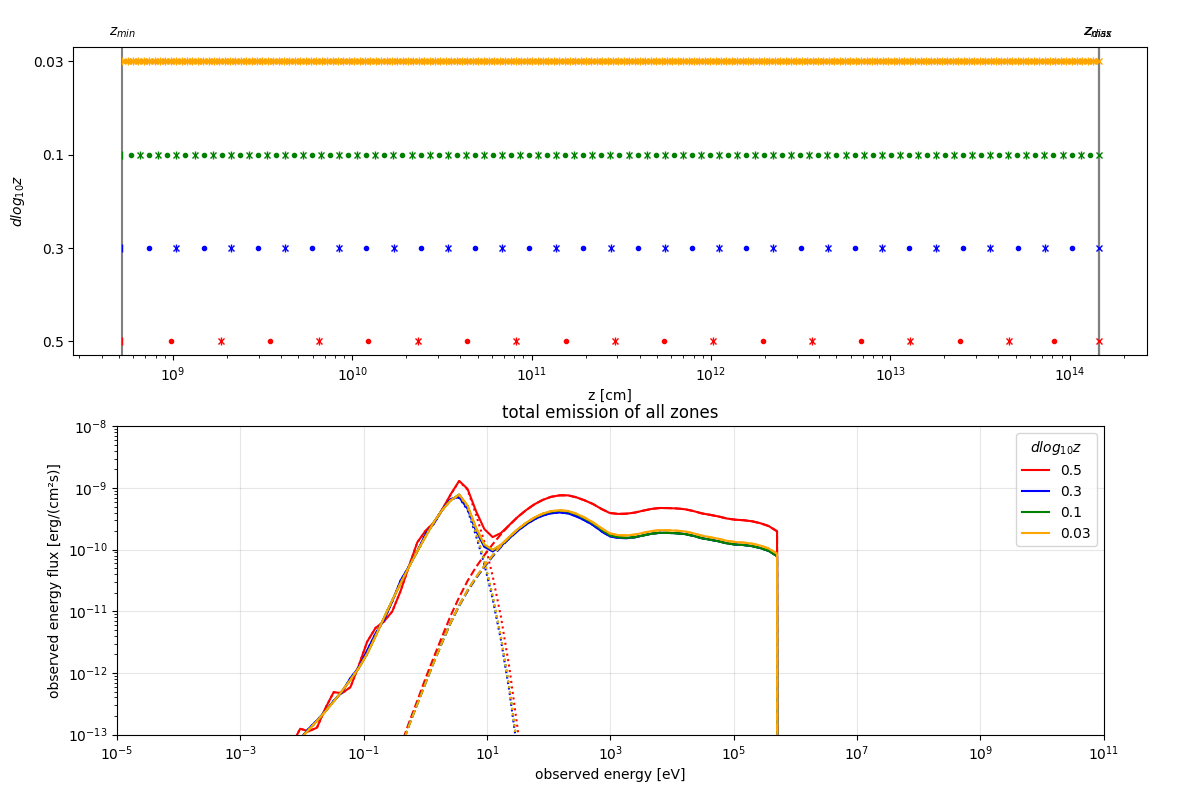

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
fig.tight_layout(pad=3.0)

cols = ["r", "b", "g", "orange", "c"]
height = 0
elements = {}

for i in range(len(dlgzs)):
    bljet = bljets[i]
    elements[i] = {}
    bljet.compute_jet_dynamics()
    elements[i]["zmin_ticks"] = ax1.semilogx(bljet.get_z_min_grid(), height*np.ones_like(bljet.get_z_min_grid()), ls="", marker="|", c=cols[i])
    elements[i]["zcen_ticks"] = ax1.semilogx(bljet.get_z_center_grid(), height*np.ones_like(bljet.get_z_min_grid()), ls="", marker=".", c=cols[i])
    elements[i]["zmax_ticks"] = ax1.semilogx(bljet.get_z_min_grid()+bljet.get_z_height_grid(), height*np.ones_like(bljet.get_z_min_grid()), ls="", marker="x", c=cols[i], ms=4)
    height += 1
ax1.axvline(bljet.z_jet_launching*bljet.r_g, zorder=0, c="grey")
ax1.text(bljet.z_jet_launching*bljet.r_g, height-0.7, r"$z_{min}$", va='center', ha="center")
elements["z_diss_line"] = ax1.axvline(bljet.z_dissipation*bljet.r_g, zorder=0, c="k")
elements["z_diss_text"] = ax1.text(bljet.z_dissipation*bljet.r_g, height-0.7, r"$z_{diss}$", va='center', ha="center")
ax1.axvline(bljet.z_max_calculation*bljet.r_g, zorder=0, c="grey")
ax1.text(bljet.z_max_calculation*bljet.r_g, height-0.7, r"$z_{max}$", va='center', ha="center")

ax1.set_xlabel("z [cm]")
ax1.set_yticks(np.arange(len(dlgzs)))
ax1.set_yticklabels(dlgzs)
ax1.set_ylabel(r"$dlog_{10}z$")

for i in range(len(dlgzs)):
    bhjet = bhjets[i]
    bljet = bljets[i]
    elements[i]["flux_tot"] = ax2.loglog(E_out, E_out*eV2erg*bhjet.get_observed_photon_integrated_flux_total(
        0, bljet.z_max_calculation*bljet.r_g), label=f"{dlgzs[i]}", color=cols[i])
    elements[i]["flux_com"] = ax2.loglog(E_out, E_out*eV2erg*bhjet.get_observed_photon_integrated_flux_electron_compton(
        0, bljet.z_max_calculation*bljet.r_g), color=cols[i], ls="--")
    elements[i]["flux_syn"] = ax2.loglog(E_out, E_out*eV2erg*bhjet.get_observed_photon_integrated_flux_electron_cyclosyn(
        0, bljet.z_max_calculation*bljet.r_g), color=cols[i], ls=":")

ax2.legend(title=r"$dlog_{10}z$")
ax2.set_title("total emission of all zones")
ax2.set_xlabel(r"observed energy [eV]")
ax2.set_ylabel(r"observed energy flux [erg/(cm²s)]")
if sim_type == "M87":
    ax2.set_ylim(1e-17, 1e-10)
elif sim_type == "xrb":
    ax2.set_ylim(1e-13, 1e-8)
else:
    ax2.set_ylim(1e-17, 1e-8)
ax2.set_xlim(1e-5, 1e11)
ax2.set_aspect("equal")
ax2.grid(alpha=0.3)

In [15]:
def update(frame):

    height = 0
    for i in range(len(dlgzs)):
        elements[i]["zmin_ticks"][0].set_xdata(plotdata["zmin_grids"][i][frame])
        elements[i]["zcen_ticks"][0].set_xdata(plotdata["zcen_grids"][i][frame])
        elements[i]["zmax_ticks"][0].set_xdata(plotdata["zmax_grids"][i][frame])

        elements["z_diss_line"].set_xdata([z_diss_vals[frame] * bljet.r_g, z_diss_vals[frame] * bljet.r_g])
        elements["z_diss_text"].set_x(z_diss_vals[frame] * bljet.r_g)

        elements[i]["flux_tot"][0].set_ydata(plotdata["Efluxs_tot"][i][frame])
        elements[i]["flux_syn"][0].set_ydata(plotdata["Efluxs_syn"][i][frame])
        elements[i]["flux_com"][0].set_ydata(plotdata["Efluxs_com"][i][frame])



In [16]:
update(20)

In [17]:

anim = animation.FuncAnimation(
    fig, update, frames=len(z_diss_vals), interval=50, blit=True
)


In [18]:
anim.save(f"grid_animations/z_dissipation_sweep_{sim_type}.gif", writer="pillow", fps=10)